In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load the data
df = pd.read_csv('Data/housing.csv')

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (20640, 10)

Column Names: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

First 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
# Step 3: Basic exploration
print("Shape:", df.shape)
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Basic Statistics ---")
df.describe()

Shape: (20640, 10)

--- Data Types ---
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

--- Missing Values ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

--- Basic Statistics ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
# Step 4: Handle missing values
# Fill missing total_bedrooms with the median (robust to outliers)
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Verify no more missing values
print("Missing values after fix:")
print(df.isnull().sum())

Missing values after fix:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


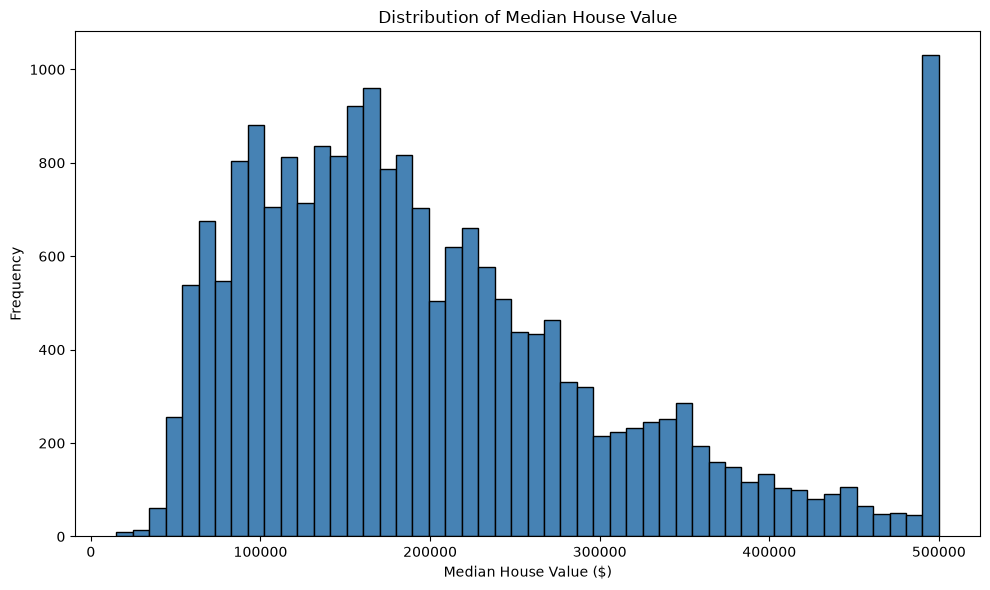

In [5]:
# Step 5: EDA - Distribution of target variable
plt.figure(figsize=(10, 6))
plt.hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Before: (20640, 10)
After: (19648, 10)


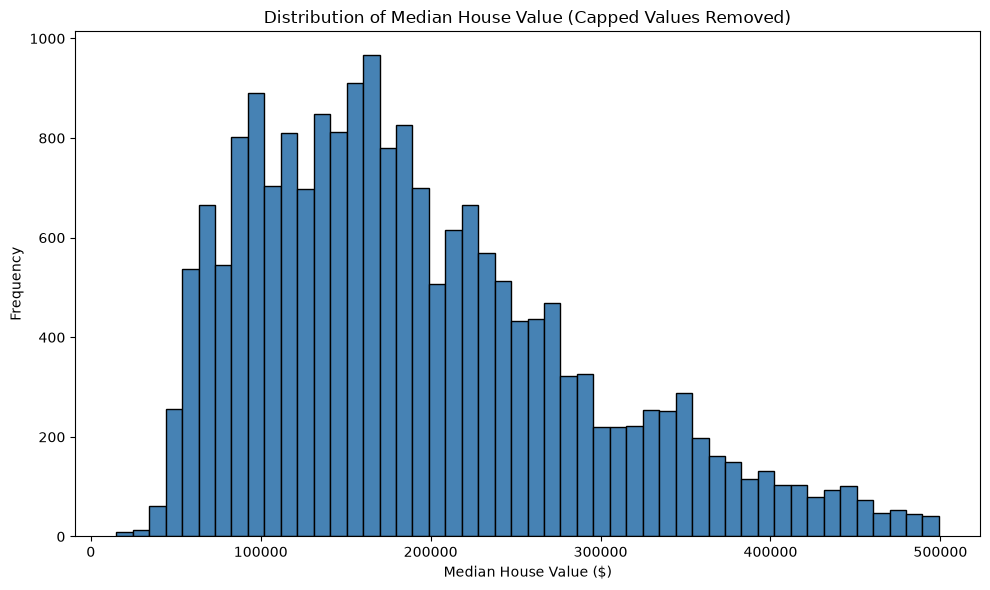

In [6]:
# Step 6: Remove capped house values (data artifact, not real prices)
print("Before:", df.shape)
df = df[df['median_house_value'] < 500000]
print("After:", df.shape)

# Re-plot to confirm
plt.figure(figsize=(10, 6))
plt.hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Median House Value (Capped Values Removed)')
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

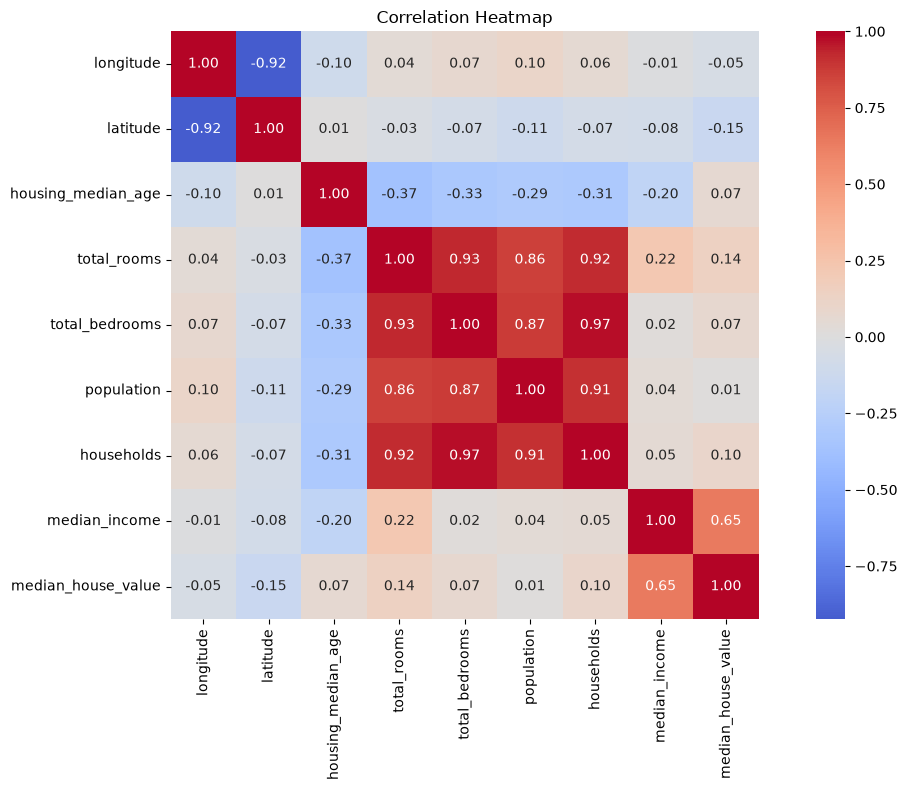

In [7]:
# Step 7: Correlation heatmap
plt.figure(figsize=(12, 8))
numerical_df = df.select_dtypes(include=[np.number])
correlation = numerical_df.corr()

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [8]:
# Step 8: Feature Engineering
# Create more meaningful features from existing ones

df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

print("New features added:")
print(df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe())

New features added:
       rooms_per_household  bedrooms_per_room  population_per_household
count         19648.000000       19648.000000              19648.000000
mean              5.361708           0.215716                  3.096560
std               2.293321           0.064626                 10.639195
min               0.846154           0.037151                  0.692308
25%               4.416667           0.177476                  2.446614
50%               5.185730           0.204543                  2.837779
75%               5.971083           0.241258                  3.306021
max             132.533333           2.824675               1243.333333


In [9]:
# Step 9: Remove outliers from engineered features
print("Before:", df.shape)

df = df[df['rooms_per_household'] < 20]
df = df[df['population_per_household'] < 20]
df = df[df['bedrooms_per_room'] < 1]

print("After:", df.shape)
print("\nNew stats after removing outliers:")
df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe()

Before: (19648, 13)
After: (19563, 13)

New stats after removing outliers:


,rooms_per_household,bedrooms_per_room,population_per_household
count,19563.000000,19563.000000,19563.000000
mean,5.269825,0.215299,2.954727
std,1.372742,0.058983,0.855436
min,0.888889,0.037151,0.750000
25%,4.413540,0.177490,2.448344
50%,5.180952,0.204545,2.839506
75%,5.961191,0.241265,3.307283
max,19.962121,0.937500,19.312500


In [10]:
# Step 10: Encode ocean_proximity (categorical → numerical)
print("Ocean proximity categories:")
print(df['ocean_proximity'].value_counts())

# One-hot encoding
df = pd.get_dummies(df, columns=['ocean_proximity'])

print("\nNew columns added:")
print(df.columns.tolist())
print("\nShape:", df.shape)

Ocean proximity categories:
ocean_proximity
<1H OCEAN     8592
INLAND        6444
NEAR OCEAN    2435
NEAR BAY      2087
ISLAND           5
Name: count, dtype: int64

New columns added:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

Shape: (19563, 17)


In [11]:
# Step 11: Define features and target
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Step 12: Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining set:", X_train.shape)
print("Test set:", X_test.shape)

Features shape: (19563, 16)
Target shape: (19563,)

Training set: (15650, 16)
Test set: (3913, 16)


In [12]:
# Step 13: Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")
print("Mean of first feature (should be ~0):", X_train_scaled[:, 0].mean().round(4))
print("Std of first feature (should be ~1):", X_train_scaled[:, 0].std().round(4))

Scaling done!
Mean of first feature (should be ~0): 0.0
Std of first feature (should be ~1): 1.0


In [13]:
# Step 14: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("=== Linear Regression Results ===")
print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²:   {r2:.4f}")

=== Linear Regression Results ===
MAE:  $43,257
RMSE: $58,503
R²:   0.6524


In [14]:
# Step 15: Random Forest
from sklearn.ensemble import RandomForestRegressor

# Train
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("=== Random Forest Results ===")
print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²:   {r2:.4f}")

=== Random Forest Results ===
MAE:  $30,045
RMSE: $44,820
R²:   0.7960


In [15]:
# Step 16: XGBoost
from xgboost import XGBRegressor

# Train
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print("=== XGBoost Results ===")
print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²:   {r2:.4f}")

=== XGBoost Results ===
MAE:  $28,495
RMSE: $42,061
R²:   0.8203


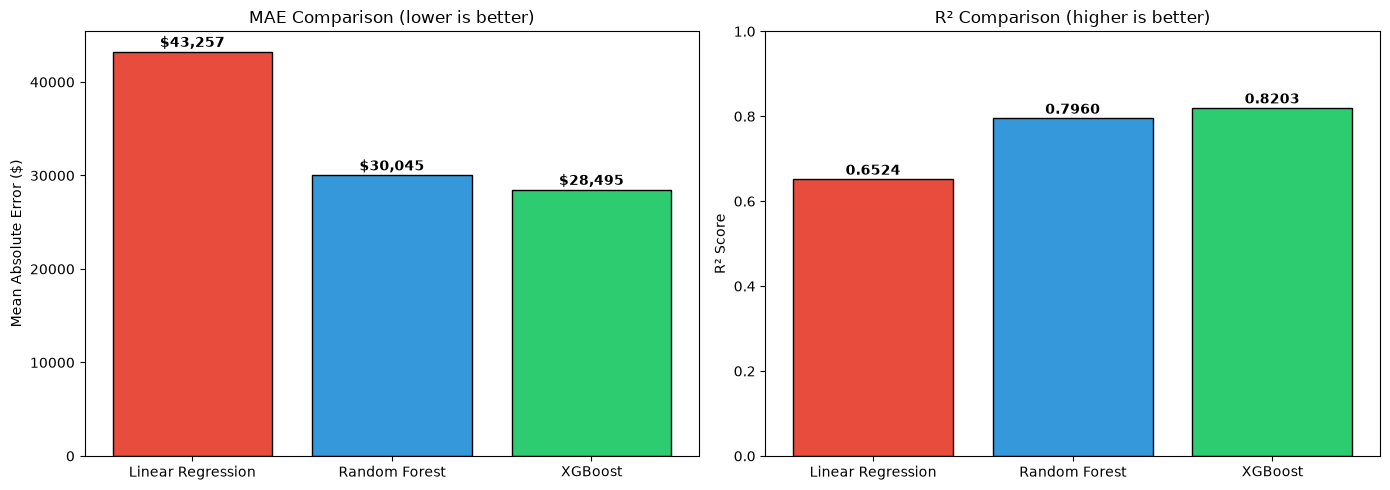

In [16]:
# Step 17: Model Comparison Chart
models = ['Linear Regression', 'Random Forest', 'XGBoost']
mae_scores = [43257, 30045, 28495]
r2_scores = [0.6524, 0.7960, 0.8203]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# MAE comparison
colors = ['#e74c3c', '#3498db', '#2ecc71']
ax1.bar(models, mae_scores, color=colors, edgecolor='black')
ax1.set_title('MAE Comparison (lower is better)')
ax1.set_ylabel('Mean Absolute Error ($)')
for i, v in enumerate(mae_scores):
    ax1.text(i, v + 500, f'${v:,}', ha='center', fontweight='bold')

# R² comparison
ax2.bar(models, r2_scores, color=colors, edgecolor='black')
ax2.set_title('R² Comparison (higher is better)')
ax2.set_ylabel('R² Score')
ax2.set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

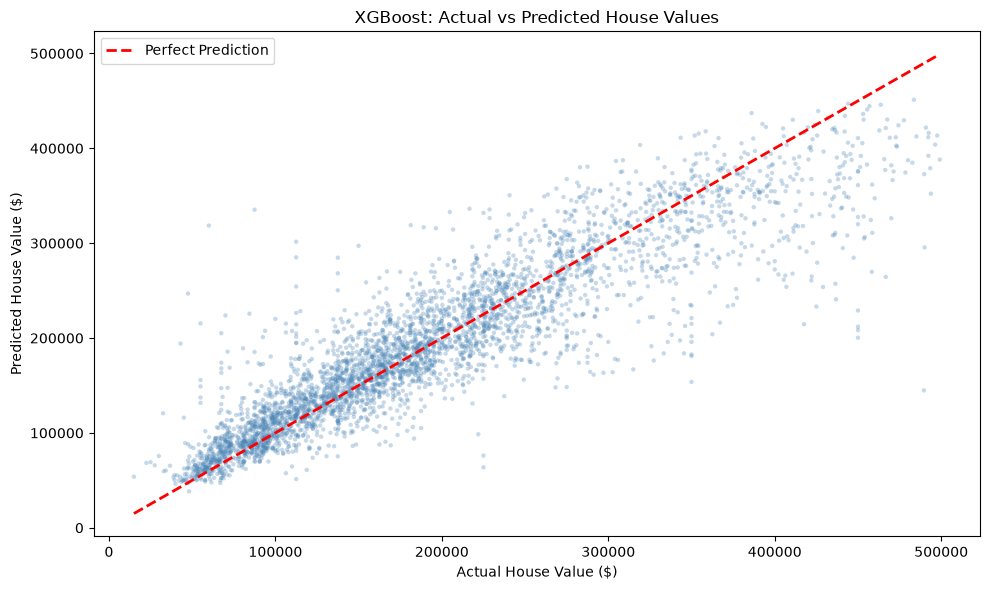

In [17]:
# Step 18: Actual vs Predicted Plot (XGBoost)
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='steelblue', edgecolors='none', s=10)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred_xgb.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual House Value ($)')
plt.ylabel('Predicted House Value ($)')
plt.title('XGBoost: Actual vs Predicted House Values')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Step 19: Save the best model and scaler
import joblib
import os

os.makedirs('models', exist_ok=True)

joblib.dump(xgb_model, 'models/best_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ Model saved to models/best_model.pkl")
print("✅ Scaler saved to models/scaler.pkl")

✅ Model saved to models/best_model.pkl
✅ Scaler saved to models/scaler.pkl
